1) Mount Drive + imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import cv2
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Input, TimeDistributed, LSTM, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2) Install face detector

In [2]:
!pip install -q mtcnn lz4
from mtcnn import MTCNN
face_detector = MTCNN()

3) Paths + config

In [3]:
# =========================
# PATHS
# =========================
BASE_PATH = "/content/drive/MyDrive/Deepfake_Project/datasets/FaceForensics++_C23"
REAL_PATH = os.path.join(BASE_PATH, "original")

FAKE_FOLDERS = [
    "Deepfakes",
    "FaceSwap",
    "Face2Face",
    "NeuralTextures",
    "FaceShifter"
]

PROJECT_ROOT = "/content/drive/MyDrive/Deepfake_Project"
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# =========================
# SETTINGS
# =========================
IMG_SIZE = 224
FRAME_COUNT = 10
MAX_REAL = 200
MAX_FAKE_PER_FOLDER = 40   # 5 folders x 40 = 200 fake
BATCH_SIZE = 4
EPOCHS = 20
LR = 1e-4
FINE_TUNE_LR = 1e-5
video_exts = (".mp4", ".avi", ".mov", ".mkv")

4) Collect dataset

In [4]:
# real videos
real_videos = [
    os.path.join(REAL_PATH, f)
    for f in os.listdir(REAL_PATH)
    if f.lower().endswith(video_exts)
]
real_videos = sorted(real_videos)[:MAX_REAL]

# fake videos from multiple manipulation methods
fake_videos = []
for folder in FAKE_FOLDERS:
    folder_path = os.path.join(BASE_PATH, folder)
    vids = [
        os.path.join(folder_path, f)
        for f in os.listdir(folder_path)
        if f.lower().endswith(video_exts)
    ]
    vids = sorted(vids)[:MAX_FAKE_PER_FOLDER]
    fake_videos.extend(vids)

print("Real videos:", len(real_videos))
print("Fake videos:", len(fake_videos))
print("Sample real:", real_videos[:3])
print("Sample fake:", fake_videos[:3])

Real videos: 200
Fake videos: 200
Sample real: ['/content/drive/MyDrive/Deepfake_Project/datasets/FaceForensics++_C23/original/000.mp4', '/content/drive/MyDrive/Deepfake_Project/datasets/FaceForensics++_C23/original/003.mp4', '/content/drive/MyDrive/Deepfake_Project/datasets/FaceForensics++_C23/original/006.mp4']
Sample fake: ['/content/drive/MyDrive/Deepfake_Project/datasets/FaceForensics++_C23/Deepfakes/000_003.mp4', '/content/drive/MyDrive/Deepfake_Project/datasets/FaceForensics++_C23/Deepfakes/003_000.mp4', '/content/drive/MyDrive/Deepfake_Project/datasets/FaceForensics++_C23/Deepfakes/006_002.mp4']


5) Face crop helper

In [5]:
def detect_and_crop_face(frame, detector, img_size=224, padding=0.2):
    h, w, _ = frame.shape
    results = detector.detect_faces(frame)

    if len(results) == 0:
        return cv2.resize(frame, (img_size, img_size))

    best = max(results, key=lambda x: x['box'][2] * x['box'][3])
    x, y, bw, bh = best['box']

    x = max(0, x)
    y = max(0, y)

    pad_x = int(bw * padding)
    pad_y = int(bh * padding)

    x1 = max(0, x - pad_x)
    y1 = max(0, y - pad_y)
    x2 = min(w, x + bw + pad_x)
    y2 = min(h, y + bh + pad_y)

    face = frame[y1:y2, x1:x2]

    if face.size == 0:
        return cv2.resize(frame, (img_size, img_size))

    return cv2.resize(face, (img_size, img_size))

6) Augmentation helper

In [6]:
def augment_frame(frame):
    # frame is RGB uint8
    if np.random.rand() < 0.5:
        frame = cv2.flip(frame, 1)

    if np.random.rand() < 0.3:
        alpha = np.random.uniform(0.9, 1.1)   # contrast
        beta = np.random.uniform(-12, 12)     # brightness
        frame = cv2.convertScaleAbs(frame, alpha=alpha, beta=beta)

    if np.random.rand() < 0.3:
        angle = np.random.uniform(-8, 8)
        h, w = frame.shape[:2]
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
        frame = cv2.warpAffine(frame, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        frame = np.expand_dims(frame, axis=-1) if frame.ndim == 2 else frame

    return frame

7) Frame extraction function

In [7]:
def extract_video_frames(
    video_path,
    detector=None,
    frame_count=10,
    img_size=224,
    use_face_crop=False,
    use_augmentation=False
):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return np.zeros((frame_count, img_size, img_size, 3), dtype=np.float32)

    indices = np.linspace(0, total_frames - 1, frame_count, dtype=int)
    frames = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if not ret:
            frame = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        else:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            if use_face_crop and detector is not None:
                frame = detect_and_crop_face(frame, detector, img_size=img_size)
            else:
                frame = cv2.resize(frame, (img_size, img_size))

            if use_augmentation:
                frame = augment_frame(frame)

        frame = frame.astype(np.float32)
        frame = preprocess_input(frame)
        frames.append(frame)

    cap.release()
    return np.array(frames, dtype=np.float32)

8) Build dataset function

In [8]:
def build_dataset(
    real_list,
    fake_list,
    detector=None,
    frame_count=10,
    img_size=224,
    use_face_crop=False,
    use_augmentation=False
):
    X = []
    y = []

    print("Processing real videos...")
    for path in tqdm(real_list):
        X.append(
            extract_video_frames(
                path,
                detector=detector,
                frame_count=frame_count,
                img_size=img_size,
                use_face_crop=use_face_crop,
                use_augmentation=use_augmentation
            )
        )
        y.append(0)

    print("Processing fake videos...")
    for path in tqdm(fake_list):
        X.append(
            extract_video_frames(
                path,
                detector=detector,
                frame_count=frame_count,
                img_size=img_size,
                use_face_crop=use_face_crop,
                use_augmentation=use_augmentation
            )
        )
        y.append(1)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    return X, y

9) Train/val/test split once

In [9]:
all_paths = real_videos + fake_videos
all_labels = [0]*len(real_videos) + [1]*len(fake_videos)

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.30,
    random_state=42,
    stratify=all_labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("Train videos:", len(train_paths))
print("Val videos:", len(val_paths))
print("Test videos:", len(test_paths))

Train videos: 280
Val videos: 60
Test videos: 60


10) Build train/val/test sets for 3 experiments

A. Baseline

In [12]:
X_train_base, y_train_base = build_dataset(
    [p for p, l in zip(train_paths, train_labels) if l == 0],
    [p for p, l in zip(train_paths, train_labels) if l == 1],
    detector=None,
    frame_count=FRAME_COUNT,
    img_size=IMG_SIZE,
    use_face_crop=False,
    use_augmentation=False
)

X_val_base, y_val_base = build_dataset(
    [p for p, l in zip(val_paths, val_labels) if l == 0],
    [p for p, l in zip(val_paths, val_labels) if l == 1],
    detector=None,
    frame_count=FRAME_COUNT,
    img_size=IMG_SIZE,
    use_face_crop=False,
    use_augmentation=False
)

X_test_base, y_test_base = build_dataset(
    [p for p, l in zip(test_paths, test_labels) if l == 0],
    [p for p, l in zip(test_paths, test_labels) if l == 1],
    detector=None,
    frame_count=FRAME_COUNT,
    img_size=IMG_SIZE,
    use_face_crop=False,
    use_augmentation=False
)

Processing real videos...


100%|██████████| 140/140 [05:58<00:00,  2.56s/it]


Processing fake videos...


100%|██████████| 140/140 [06:02<00:00,  2.59s/it]


Processing real videos...


...

100%|██████████| 30/30 [01:14<00:00,  2.49s/it]


Processing real videos...


100%|██████████| 30/30 [01:09<00:00,  2.30s/it]


Processing fake videos...


100%|██████████| 30/30 [01:18<00:00,  2.60s/it]


B. Face crop

In [13]:
X_train_face, y_train_face = build_dataset(
    [p for p, l in zip(train_paths, train_labels) if l == 0],
    [p for p, l in zip(train_paths, train_labels) if l == 1],
    detector=face_detector,
    frame_count=FRAME_COUNT,
    img_size=IMG_SIZE,
    use_face_crop=True,
    use_augmentation=False
)

X_val_face, y_val_face = build_dataset(
    [p for p, l in zip(val_paths, val_labels) if l == 0],
    [p for p, l in zip(val_paths, val_labels) if l == 1],
    detector=face_detector,
    frame_count=FRAME_COUNT,
    img_size=IMG_SIZE,
    use_face_crop=True,
    use_augmentation=False
)

X_test_face, y_test_face = build_dataset(
    [p for p, l in zip(test_paths, test_labels) if l == 0],
    [p for p, l in zip(test_paths, test_labels) if l == 1],
    detector=face_detector,
    frame_count=FRAME_COUNT,
    img_size=IMG_SIZE,
    use_face_crop=True,
    use_augmentation=False
)

Processing real videos...


100%|██████████| 140/140 [15:39<00:00,  6.71s/it]


Processing fake videos...


100%|██████████| 140/140 [15:26<00:00,  6.62s/it]


Processing real videos...


...

100%|██████████| 30/30 [03:23<00:00,  6.79s/it]


Processing real videos...


100%|██████████| 30/30 [03:23<00:00,  6.77s/it]


Processing fake videos...


100%|██████████| 30/30 [03:33<00:00,  7.13s/it]


C. Face crop + augmentation

In [10]:
X_train_aug, y_train_aug = build_dataset(
    [p for p, l in zip(train_paths, train_labels) if l == 0],
    [p for p, l in zip(train_paths, train_labels) if l == 1],
    detector=face_detector,
    frame_count=FRAME_COUNT,
    img_size=IMG_SIZE,
    use_face_crop=True,
    use_augmentation=True
)

X_val_aug, y_val_aug = build_dataset(
    [p for p, l in zip(val_paths, val_labels) if l == 0],
    [p for p, l in zip(val_paths, val_labels) if l == 1],
    detector=face_detector,
    frame_count=FRAME_COUNT,
    img_size=IMG_SIZE,
    use_face_crop=True,
    use_augmentation=False
)

X_test_aug, y_test_aug = build_dataset(
    [p for p, l in zip(test_paths, test_labels) if l == 0],
    [p for p, l in zip(test_paths, test_labels) if l == 1],
    detector=face_detector,
    frame_count=FRAME_COUNT,
    img_size=IMG_SIZE,
    use_face_crop=True,
    use_augmentation=False
)

Processing real videos...


100%|██████████| 140/140 [15:57<00:00,  6.84s/it]


Processing fake videos...


100%|██████████| 140/140 [15:08<00:00,  6.49s/it]


Processing real videos...


...

100%|██████████| 30/30 [03:19<00:00,  6.64s/it]


Processing real videos...


100%|██████████| 30/30 [03:15<00:00,  6.52s/it]


Processing fake videos...


100%|██████████| 30/30 [03:36<00:00,  7.23s/it]


11) Model builder

In [11]:
def build_cnn_lstm_model(img_size=224, frame_count=10, learning_rate=1e-4):
    cnn_base = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(img_size, img_size, 3)
    )
    cnn_base.trainable = False

    frame_input = Input(shape=(frame_count, img_size, img_size, 3))

    x = TimeDistributed(cnn_base)(frame_input)
    x = TimeDistributed(GlobalAveragePooling2D())(x)

    x = LSTM(64, return_sequences=False)(x)
    x = Dropout(0.4)(x)
    x = Dense(32, activation="relu")(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=frame_input, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

12) Train helper

In [12]:
def train_model(model, X_train, y_train, X_val, y_val, save_path, epochs=20, batch_size=4):
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
        ModelCheckpoint(save_path, monitor="val_loss", save_best_only=True, verbose=1)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )
    return history

13) Evaluation helper

In [13]:
def evaluate_model(model, X_test, y_test, exp_name):
    y_prob = model.predict(X_test).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n===== {exp_name} =====")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-score :", f1)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred, target_names=["Real", "Fake"]))

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Real", "Fake"],
                yticklabels=["Real", "Fake"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - {exp_name}")
    plt.show()

    return {
        "experiment": exp_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1
    }

14) Plot helper

In [14]:
def plot_history(history, title):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="train acc")
    plt.plot(history.history["val_accuracy"], label="val acc")
    plt.title(f"{title} - Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="train loss")
    plt.plot(history.history["val_loss"], label="val loss")
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

15) Run the 3 experiments

Experiment 1

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5366 - loss: 0.7298
Epoch 1: val_loss improved from None to 0.68028, saving model to /content/drive/MyDrive/Deepfake_Project/models/baseline.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Deepfake_Project/models/baseline.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - accuracy: 0.5321 - loss: 0.7333 - val_accuracy: 0.6000 - val_loss: 0.6803 - learning_rate: 1.0000e-04
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6077 - loss: 0.6779
Epoch 2: val_loss improved from 0.68028 to 0.66568, saving model to /content/drive/MyDrive/Deepfake_Project/models/baseline.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Deepfake_Project/models/baseline.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.5571 - loss: 0.6970 - val_accuracy: 0.6167 - val_loss: 0.6657 - learning_rate: 1.0000e-04
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/st

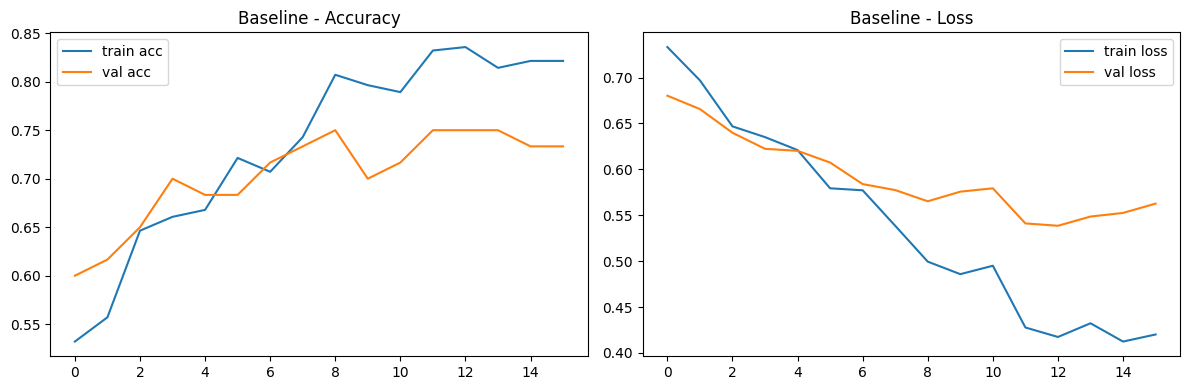

2/2 ━━━━━━━━━━━━━━━━━━━━ 60s 29s/step

===== Baseline =====
Accuracy : 0.7
Precision: 0.6875
Recall   : 0.7333333333333333
F1-score : 0.7096774193548387

Classification Report:

              precision    recall  f1-score   support

        Real       0.71      0.67      0.69        30
        Fake       0.69      0.73      0.71        30

    accuracy                           0.70        60
   macro avg       0.70      0.70      0.70        60
weighted avg       0.70      0.70      0.70        60



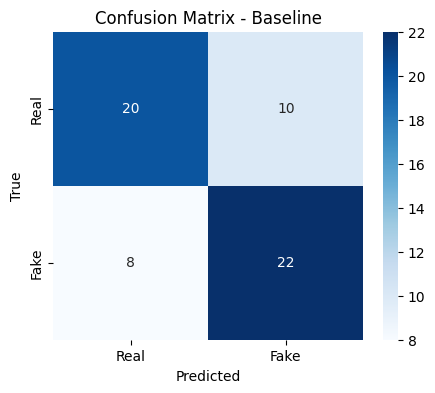

In [17]:
model_base = build_cnn_lstm_model(IMG_SIZE, FRAME_COUNT, LR)
history_base = train_model(
    model_base,
    X_train_base, y_train_base,
    X_val_base, y_val_base,
    save_path=os.path.join(MODELS_DIR, "baseline.keras"),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)
plot_history(history_base, "Baseline")
res_base = evaluate_model(model_base, X_test_base, y_test_base, "Baseline")

Experiment 2

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4125 - loss: 0.7834
Epoch 1: val_loss improved from None to 0.68400, saving model to /content/drive/MyDrive/Deepfake_Project/models/face_crop.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Deepfake_Project/models/face_crop.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.4607 - loss: 0.7390 - val_accuracy: 0.5667 - val_loss: 0.6840 - learning_rate: 1.0000e-04
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5564 - loss: 0.6840
Epoch 2: val_loss did not improve from 0.68400
70/70 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.5500 - loss: 0.6922 - val_accuracy: 0.5500 - val_loss: 0.6903 - learning_rate: 1.0000e-04
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5907 - loss: 0.6749
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 3: val_loss did not improve from 0.68400
70/70 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.5750 - loss:

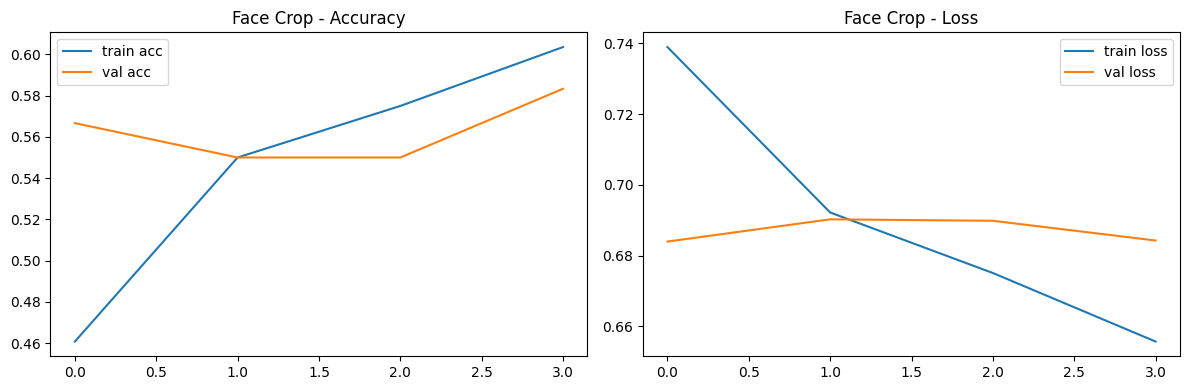

2/2 ━━━━━━━━━━━━━━━━━━━━ 59s 28s/step

===== Face Crop =====
Accuracy : 0.5833333333333334
Precision: 0.6
Recall   : 0.5
F1-score : 0.5454545454545454

Classification Report:

              precision    recall  f1-score   support

        Real       0.57      0.67      0.62        30
        Fake       0.60      0.50      0.55        30

    accuracy                           0.58        60
   macro avg       0.59      0.58      0.58        60
weighted avg       0.59      0.58      0.58        60



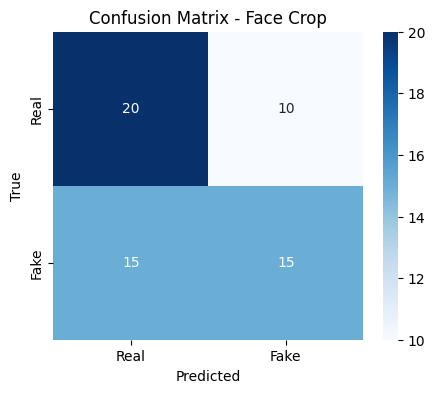

In [20]:
model_face = build_cnn_lstm_model(IMG_SIZE, FRAME_COUNT, LR)
history_face = train_model(
    model_face,
    X_train_face, y_train_face,
    X_val_face, y_val_face,
    save_path=os.path.join(MODELS_DIR, "face_crop.keras"),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)
plot_history(history_face, "Face Crop")
res_face = evaluate_model(model_face, X_test_face, y_test_face, "Face Crop")

Experiment 3

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4516 - loss: 0.7716
Epoch 1: val_loss improved from None to 0.69883, saving model to /content/drive/MyDrive/Deepfake_Project/models/face_crop_aug.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Deepfake_Project/models/face_crop_aug.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.4571 - loss: 0.7425 - val_accuracy: 0.4500 - val_loss: 0.6988 - learning_rate: 1.0000e-04
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5433 - loss: 0.7011
Epoch 2: val_loss improved from 0.69883 to 0.69146, saving model to /content/drive/MyDrive/Deepfake_Project/models/face_crop_aug.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Deepfake_Project/models/face_crop_aug.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.5321 - loss: 0.7069 - val_accuracy: 0.5333 - val_loss: 0.6915 - learning_rate: 1.0000e-04
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5862 - loss:

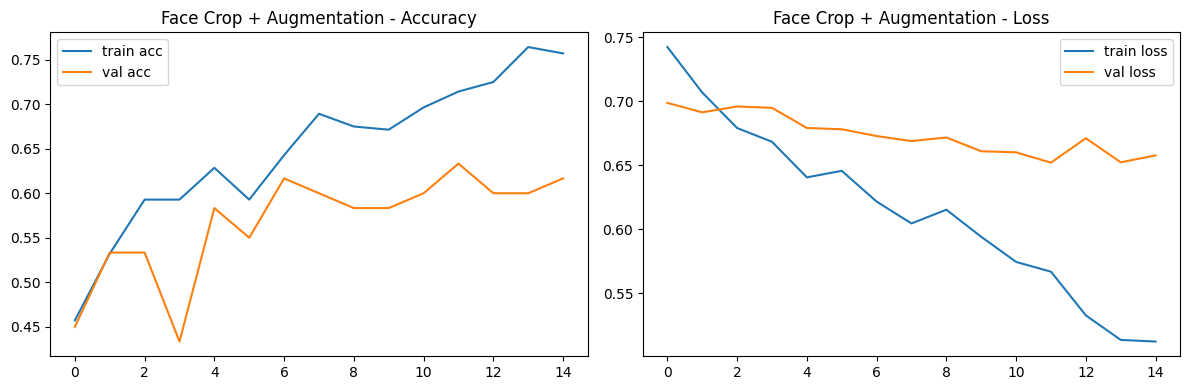

2/2 ━━━━━━━━━━━━━━━━━━━━ 60s 30s/step

===== Face Crop + Augmentation =====
Accuracy : 0.65
Precision: 0.6451612903225806
Recall   : 0.6666666666666666
F1-score : 0.6557377049180327

Classification Report:

              precision    recall  f1-score   support

        Real       0.66      0.63      0.64        30
        Fake       0.65      0.67      0.66        30

    accuracy                           0.65        60
   macro avg       0.65      0.65      0.65        60
weighted avg       0.65      0.65      0.65        60



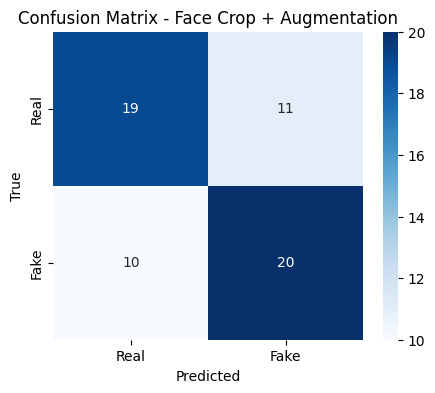

In [15]:
model_aug = build_cnn_lstm_model(IMG_SIZE, FRAME_COUNT, LR)
history_aug = train_model(
    model_aug,
    X_train_aug, y_train_aug,
    X_val_aug, y_val_aug,
    save_path=os.path.join(MODELS_DIR, "face_crop_aug.keras"),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)
plot_history(history_aug, "Face Crop + Augmentation")
res_aug = evaluate_model(model_aug, X_test_aug, y_test_aug, "Face Crop + Augmentation")